In [1]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

In [70]:
D = 2
v = 0.1
k = 0.005
L = 10
j0= -3

# The equation
$$
    \begin{cases}
    &Dy'' - vy' - ky = 0\\
    &Dy'(0) - vy(0) = j0\\
    &Dy'(L) - vy(L) = 0
    \end{cases}
$$

or with the solver

\begin{equation}
    \begin{cases}
        &y' = z \\
        &z' = ky + vz
    \end{cases}
\end{equation}

In [76]:
def f(t,y):
    return np.array([y[1], k/D*y[0] + v/D*y[1]])

def bc(y0, yL):
    return np.array([y0[1] - v/D*y0[0] - j0/D,
                     yL[1] - v/D*yL[0]])


# For the analytical steady state
sqrtD = np.sqrt(v**2 + 4 * D * k)
E2L = np.exp(-L/D*sqrtD)

def Eplus(x):
    return np.exp(x/2/D * sqrtD)

def Eminus(x):
    return np.exp(-x/2/D * sqrtD)

def ss(x):
    left = 2*j0/(E2L - 1)
    right_1 = (E2L*Eplus(x)/(sqrtD - v))
    right_2 = (Eminus(x)/(sqrtD + v))

    return left*(right_1 + right_2)

x = np.linspace(0,L,1000)
yi = np.zeros((2,x.shape[0]))

yi[0,500] = 1

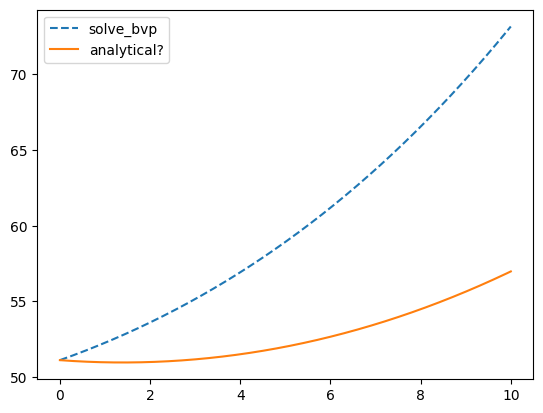

In [78]:
res = solve_bvp(f, bc, x, yi)

x_plot = np.linspace(0,L,1000)
y_plot = res.sol(x_plot)[0]

fig, ax = plt.subplots(1,1)
ax.plot(x_plot, y_plot, linestyle='--', label='solve_bvp')
# ax.set_ylim(0, y_plot.max()*1.1);
ax.plot(x_plot, ss(x_plot), label='analytical?')
ax.legend()


In [82]:
yL = y_plot[0]
yyL = (y_plot[1] - y_plot[0])/0.01

print(D*yyL, v*yL + j0)

2.116279821787259 2.112355471131731
